In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,accuracy_score,ConfusionMatrixDisplay,classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchaudio.transforms as T
from torch.utils.data import Dataset,DataLoader

from tqdm.notebook import tqdm

SR = 22050
DURATION = 30

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("kgg_key")
secret_value_1 = user_secrets.get_secret("kgg_user")
secret_value_2 = user_secrets.get_secret("WANDB_API_KEY")


#============ Check for GPU availability ==============================#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    print("GPU is available.Setting RANDOM_SEED .... ")
        # setting for both CPU and GPU
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("   Running on CPU")
print("\n✅ Environment setup complete!")

import warnings
warnings.filterwarnings("ignore")

🚀 Using device: cuda
GPU is available.Setting RANDOM_SEED .... 
   GPU: Tesla T4
   Memory: 14.6 GB

✅ Environment setup complete!


First Neural Network & CNNs!

* Learn PyTorch basics: Tensors, Dataset (custom loader for training), DataLoader.
* Convert audio to 2D/1D Mel-Spectrograms.
* Build a simple CNN (Convolutional Neural Network)/NN (Neural Network) to process the spectrograms.
* Implement training loop, loss, optimizer, and wandb logging.
* Train and evaluate your CNN/NN (Neural Network)model.

# Definition

## - Utility

In [2]:
def extract_paths(pc=5000,ts=500):
    GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
    train_paths = []
    val_paths = []
    count = 0
    tr_count = 0
    val_count = 0
    
    
    for g in GENRES:
        root_dir_path = f"/kaggle/input/datasets/akashkumbhakar/{g}-mel-t5000-v500"
        for i in range(0,pc):
            if i < ts:
                val_file_name = f"val/mashup_v2_{i}.npy"
                val_path =  os.path.join(root_dir_path,val_file_name)
                val_paths.append((val_path,g))
                val_count += 1
            train_file_name = f"train/mashup_v2_{i}.npy"
            train_path = os.path.join(root_dir_path,train_file_name)
            train_paths.append((train_path,g))
            tr_count += 1
            count += 1
    print("Total paths (music files) : ", count)
    print("Total training files : ", tr_count)
    print("Total validation files : ", val_count)
    return train_paths,val_paths

def check_split():
    GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
    g_c = {}
    for i in tr:
        if i[1] in g_c.keys():
            g_c[i[1]] += 1
        else:
            g_c[i[1]] = 1
    return g_c

def genre_to_idx(str_label):
    genre_to_id = {'blues':0, 'classical':1, 'country':2, 'disco':3, 'hiphop':4,'jazz':5, 'metal':6, 'pop':7, 'reggae':8, 'rock':9}
    y = genre_to_id[str_label]

    return y

def idx_to_genre(targets):
    id_to_genre = {0:'blues', 1:'classical', 2:'country', 3:'disco', 4:'hiphop',5:'jazz', 6:'metal', 7:'pop', 8:'reggae', 9:'rock'}
    y = [id_to_genre[id] for id in targets]

    return y    
print("✅ defined successfully.")

✅ defined successfully.


## - Dataset and DataLoader

In [3]:
class MelDataset(Dataset):
    def __init__(self,paths,transform):  # paths : List[(path,label)]
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self,idx):
        mel = np.load(self.paths[idx][0])
        label = genre_to_idx(self.paths[idx][1])
        #mel = torch.from_numpy(mel).float()
        mel = self.transform(mel)
        label = torch.tensor(label, dtype=torch.long)
        return mel,label

data_transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[-42.67], std=[14.56]),
    T.FrequencyMasking(freq_mask_param=15),
    T.TimeMasking(time_mask_param=40)
])
print("✅ ")

✅ 


## - Coonfig

In [4]:
config = {
    "model_name" : "deep-clstm",
    "version" : 'v1',
    "batch_size" : 64,
    "lr" : 0.0001,
    "epochs" : 50,
    "sample_count" : 0,
    "log_wandb" : False,
    "description" : "This CLSTM model newly trained on properly augmented and separated trianing and validation data."
}

try:
    dir_path = f"/kaggle/working/{config['model_name']}"
    os.makedirs(dir_path, exist_ok=True)
    print(f"Directory created at: {dir_path}")
except Exception as e:
    print(f"Error creating directory: {e}")

Directory created at: /kaggle/working/deep-clstm


In [5]:
train_paths,val_paths = extract_paths(pc=5000,ts=500)

train_dataset = MelDataset(train_paths,data_transformer)
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)
val_dataset = MelDataset(val_paths,data_transformer)
val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)
config['sample_count'] = len(train_paths)
print(f"✅ BATCH SIZE : {config['batch_size']} | Size of Train Dataloader : {len(train_loader)}  |  Size of Val Dataloader : {len(val_loader)}")

Total paths (music files) :  50000
Total training files :  50000
Total validation files :  5000
✅ BATCH SIZE : 64 | Size of Train Dataloader : 782  |  Size of Val Dataloader : 79


In [13]:
#==GLOBAL MEAN AND STD ==#
#count = 0
#sum_ = 0.0
#sum_sq = 0.0

#for i,(mel,_) in tqdm(enumerate(train_loader),total=len(train_loader)):
#    mel = mel.float()
    
#    sum_ += mel.sum().item()
#    sum_sq += (mel ** 2).sum().item()
#    count += mel.numel()

#mean = sum_ / count
#std = ((sum_sq / count) - (mean ** 2)) ** 0.5
#print(mean,std)

## - Model

In [6]:
class MelCLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        #self.cnn =  nn.Sequential()
        # First convolutional block
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2,2)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2,2)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2,2)


        #self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        # Fully connected head
        #self.fc1 = nn.Linear(64, 128)
        #self.dropout = nn.Dropout(0.5)
        #self.fc2 = nn.Linear(128, num_classes)
        self.lstm = nn.LSTM(
            1024,
            hidden_size=64,
            batch_first=True,
            num_layers=1,
            bidirectional=True
        )
        self.fc = nn.Linear(64*2, num_classes)

    def forward(self, x):

        # INPUT :  (B,1,128,647)

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))  
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        #SHAPE Here : (B,64,16,80)
        #x = self.global_pool(x)
        #x = x.view(x.size(0), -1)
        #x = F.relu(self.fc1(x))
        #x = self.dropout(x)
        #x = self.fc2(x)
        batch,channel,freq,time = x.size()
        #print(batch,channel,freq,time)
        x_rnn_in = x.permute(0, 3, 1, 2).reshape(batch,time,channel*freq)
        x_rnn_out, _hc= self.lstm(x_rnn_in)
        pooled_x,_ = torch.max(x_rnn_out, dim=1)
        out_logit = self.fc(pooled_x)        
        return out_logit

model = MelCLSTM(10)
grad_param_count = 0
total_pram_count = 0
for name,p in model.named_parameters():
    mark = ""
    total_pram_count += p.numel()
    if p.requires_grad:
        mark = "[RG]" # [RG] for gradient computation
        grad_param_count += p.numel()
    print(mark," ",name," - ",p.size()," - ",p.numel())

print(f"\nTotal Parameter : {total_pram_count}\nParameters with Gradient : {grad_param_count}")

[RG]   conv1.weight  -  torch.Size([16, 1, 3, 3])  -  144
[RG]   conv1.bias  -  torch.Size([16])  -  16
[RG]   bn1.weight  -  torch.Size([16])  -  16
[RG]   bn1.bias  -  torch.Size([16])  -  16
[RG]   conv2.weight  -  torch.Size([32, 16, 3, 3])  -  4608
[RG]   conv2.bias  -  torch.Size([32])  -  32
[RG]   bn2.weight  -  torch.Size([32])  -  32
[RG]   bn2.bias  -  torch.Size([32])  -  32
[RG]   conv3.weight  -  torch.Size([64, 32, 3, 3])  -  18432
[RG]   conv3.bias  -  torch.Size([64])  -  64
[RG]   bn3.weight  -  torch.Size([64])  -  64
[RG]   bn3.bias  -  torch.Size([64])  -  64
[RG]   lstm.weight_ih_l0  -  torch.Size([256, 1024])  -  262144
[RG]   lstm.weight_hh_l0  -  torch.Size([256, 64])  -  16384
[RG]   lstm.bias_ih_l0  -  torch.Size([256])  -  256
[RG]   lstm.bias_hh_l0  -  torch.Size([256])  -  256
[RG]   lstm.weight_ih_l0_reverse  -  torch.Size([256, 1024])  -  262144
[RG]   lstm.weight_hh_l0_reverse  -  torch.Size([256, 64])  -  16384
[RG]   lstm.bias_ih_l0_reverse  -  torch.

## - Training

In [7]:
def train(model,train_loader,val_loader,loss_fn, optimizer,config):
    train_loss = []
    train_f1_score = []
    counter = 0
    patience = 4
    max_f1 = 0.0
    # initialization of wandb
    log_wandb = config["log_wandb"]
    run = None
    if log_wandb:
        run = wandb.init(
            entity="23f1001065-indian-institute-of-technology-madras",
            project="23f1001065-t12026",
            name=config['run_name'],
            config = config
        )
    num_epochs = config['epochs']
    for epoch in range(num_epochs):
        running_loss = 0.0
        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader),desc=f"Epoch {epoch+1}/{num_epochs}")
        model.train()
        for i,(mels,labels) in progress_bar:
            mels , labels = mels.to(device,non_blocking=True), labels.to(device,non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(mels)
            loss = loss_fn(outputs, labels)
        
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            avg_loss = running_loss / (i + 1)

            progress_bar.set_postfix({
                'loss': f"{avg_loss:.4f}"
            })
        loss = running_loss / len(train_loader)
        t,p,f1score,val_loss,auc = validation(model,val_loader,criterion)
        print(f"Train Loss: {loss:.4f}, Validation Loss : {val_loss},  F1_score : {f1score}, aucuracy : {auc}")
        
        # Upload metrics
        if run:
            run.log({
                "train_loss" : float(loss),
                "val_loss" : float(val_loss),
                "f1_score" : float(f1score),
                "val_accuracy" : float(auc)
            })
        if f1score > max_f1:
            max_f1 = f1score
            counter = 0
            torch.save(model.state_dict(), f"/kaggle/working/{config['model_name']}/model_at_{epoch}.pth")
        else:
            counter += 1
        # Early stopping
        #if counter >= patience:
            #print("Early stopping triggered.")
            #break
            
            
    # Close Wandb
    if run:
        run.finish()

## - Evaluation

In [8]:
def validation(model,val_loader,loss_fn):
    val_loss = 0.0
    all_true = []
    all_pred = []
    with torch.no_grad():
        model.eval()
        progress_bar = tqdm(enumerate(val_loader), total=len(val_loader),desc=f"Validation")
        for i,(mels,labels) in progress_bar:
            mels,labels = mels.to(device,non_blocking=True),labels.to(device,non_blocking=True)
            output = model(mels)
            loss = loss_fn(output,labels)

            probs = torch.softmax(output,dim=1) 
            predicted_y = torch.argmax(probs,dim=1)
            
            val_loss += loss.item()
            avg_loss = val_loss / (i + 1)

            progress_bar.set_postfix({
                'loss': f"{avg_loss:.4f}"
            })

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(predicted_y.cpu().numpy())
        #all_true = torch.cat(all_true,dim=0)
        #all_pred = torch.cat(all_pred,dim=0).cpu().numpy()
        #print(len(all_true),len(all_pred))
    
        loss = val_loss/len(val_loader)
        f1score = f1_score(all_true,all_pred,average='macro')
        val_auc_score = accuracy_score(all_true,all_pred)
        
        return all_true,all_pred,f1score,loss,val_auc_score

# Wandb login

In [9]:
while True:
    choice = input("Dou you want to log at WanDb[YES/NO] ?")
    if choice in ['YES','NO']:
        break
    else:
        print("Invalid input : Please enter 'YES' or 'NO'.")
if choice == 'YES':
    config["log_wandb"] = True
    print("Continuing....")
    import wandb
    print(f"Wandb version: {wandb.__version__}")
    wandb.login(key=secret_value_2)
else:
    config["log_wandb"] = False
    print("Aborting.")

Dou you want to log at WanDb[YES/NO] ? YES


Continuing....
Wandb version: 0.24.0


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f1001065 (23f1001065-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Training

## - setup

In [10]:
model = MelCLSTM(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

run_name = "-".join([str(attribute) for attribute in list(config.values())[:6]])
config['run_name'] = run_name

config

{'model_name': 'deep-clstm',
 'version': 'v1',
 'batch_size': 64,
 'lr': 0.0001,
 'epochs': 50,
 'sample_count': 50000,
 'log_wandb': True,
 'description': 'This CLSTM model newly trained on properly augmented and separated trianing and validation data.',
 'run_name': 'deep-clstm-v1-64-0.0001-50-50000'}

## - train

In [11]:
train(model,train_loader,val_loader,criterion, optimizer,config)

Epoch 1/50:   0%|          | 0/782 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 1.4354, Validation Loss : 1.163036372842668,  F1_score : 0.6292390307767013, aucuracy : 0.6356


Epoch 2/50:   0%|          | 0/782 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

...

Train Loss: 0.0293, Validation Loss : 0.7885224711668642,  F1_score : 0.8052831276024994, aucuracy : 0.8112


Epoch 50/50:   0%|          | 0/782 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.0309, Validation Loss : 0.761255134132844,  F1_score : 0.8063465020165206, aucuracy : 0.8126


f1_score,▁▂▄▄▅▅▆▆▇▆▆▇▇▇▇▅▇█▆██▇█▇█▇▇████▇▇▇█▇█▇█▇
train_loss,█▅▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▂▄▄▅▅▆▆▆▇▆▆▇▇▇▇▇▇█▆██▇█▇█▇▇█▇██▇▇▇▇▇▇█▇
val_loss,█▆▄▃▃▃▂▂▂▁▂▂▁▁▁▁▁▄▁▁▁▁▂▂▁▂▂▂▄▂▂▃▃▃▂▄▃▄▂▃
f1_score,0.80635
train_loss,0.03091
val_accuracy,0.8126
val_loss,0.76126


# Testing best model state dict

In [13]:
b_model = MelCLSTM(10).to(device)

best_model_file = "model_at_37.pth"
best_model_path = f"/kaggle/working/{config['model_name']}/{best_model_file}"

best_model_state = torch.load(best_model_path,map_location=torch.device(device))
b_model.load_state_dict(best_model_state)

<All keys matched successfully>

In [14]:
all_true,all_pred,f1score,loss,auc = validation(b_model,val_loader,criterion)
print(f1score,loss,auc)

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

0.8214290639579819 0.6254835856866233 0.823


              precision    recall  f1-score   support

       blues       0.84      0.74      0.79       500
   classical       0.99      1.00      0.99       500
     country       0.78      0.92      0.84       500
       disco       0.83      0.77      0.80       500
      hiphop       0.77      0.76      0.77       500
        jazz       0.96      0.98      0.97       500
       metal       0.84      0.83      0.84       500
         pop       0.91      0.89      0.90       500
      reggae       0.62      0.55      0.58       500
        rock       0.70      0.80      0.74       500

    accuracy                           0.82      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.82      0.82      0.82      5000



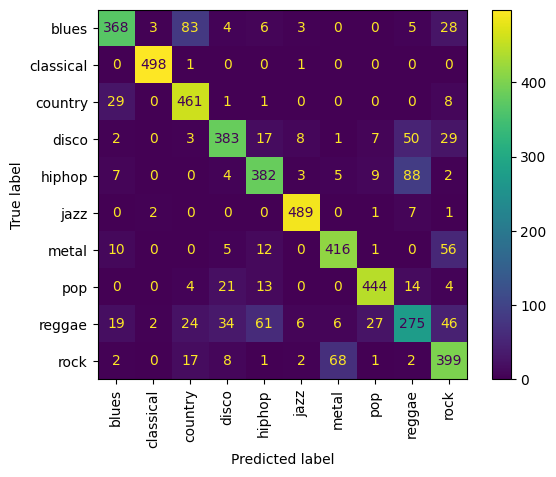

In [15]:
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
cr = classification_report(idx_to_genre(all_true),idx_to_genre(all_pred),labels=classes)
print(cr)
ConfusionMatrixDisplay.from_predictions(idx_to_genre(all_true),idx_to_genre(all_pred),labels=classes,xticks_rotation='vertical')
plt.show()

# Saving model

In [16]:
model_name = config['model_name']
if os.path.exists(f"/kaggle/working/{model_name}"):
    checkpoint = {
        "model_state" : best_model_state,
        "epoch_trained" : config['epochs'],
        "lr" : config['lr'],
        "batch_size" : config['batch_size'],
        "sample" : config['sample_count']
    }
    torch.save(checkpoint, f"/kaggle/working/checkpoint.pth")
    print(f"✅ {model_name} saved.")
else:
    print(f"Path not exists.")

✅ deep-clstm saved.


# Uploading to KaggleHub

In [17]:
import kagglehub

# Replace with path to directory containing model files.
model_name = config['model_name']
LOCAL_MODEL_DIR = f"/kaggle/working/checkpoint.pth"

MODEL_SLUG = model_name # Replace with model slug.

# Learn more about naming model variations at
# https://www.kaggle.com/docs/models#name-model.
VARIATION_SLUG = 'default' # Replace with variation slug.

kagglehub.model_upload(
  handle = f"akashkumbhakar/{MODEL_SLUG}/pyTorch/{VARIATION_SLUG}",
  local_model_dir = LOCAL_MODEL_DIR,
  version_notes = '')

Uploading Model https://api.kaggle.com/models/akashkumbhakar/deep-clstm/pyTorch/default ...
Model 'deep-clstm' does not exist or access is forbidden for user 'akashkumbhakar'. Creating or handling Model...
Model 'deep-clstm' Created.
Starting upload for file /kaggle/working/checkpoint.pth


Uploading: 100%|██████████| 2.34M/2.34M [00:00<00:00, 11.4MB/s]

Upload successful: /kaggle/working/checkpoint.pth (2MB)


Your model instance has been created.
Files are being processed...
See at: https://api.kaggle.com/models/akashkumbhakar/deep-clstm/pyTorch/default


In [ ]:
import shutil
shutil.rmtree()
print(f"{}  removed")